# Support Vector Classification with a Linear Kernel

This notebook performs binary classification on generated data clusters using:
1. Generating synthetic 2D data with two clusters
2. Training a Support Vector Classifier with a linear kernel
3. Creating a decision boundary visualisation
4. Displaying the classification results

The SVM algorithm finds the optimal hyperplane that maximises the margin
between the two classes. With a linear kernel this boundary is a straight line.

## Generate Synthetic Data

Two well-separated Gaussian blobs are generated as a simple linearly separable
binary classification problem.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC

# Generate synthetic data with two clusters
X, Y = make_blobs(n_samples=500, centers=2,
                  random_state=0, cluster_std=0.6)

## Train Linear SVM

A Support Vector Classifier with a linear kernel is fitted on the data.
The linear kernel finds the maximum-margin hyperplane directly in input space.

In [2]:
model = SVC(kernel='linear')
model.fit(X, Y)  # Train the SVM model on the generated data

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## Create Decision Boundary Grid

To visualise the decision boundary, the model's decision function is evaluated
over a dense grid covering the data range. `np.c_` assembles the flattened
grid coordinates into the (N, 2) shape expected by the model.

In [3]:
xx1, xx2 = np.meshgrid(
    np.linspace(X[:, 0].min(), X[:, 0].max(), 500),
    np.linspace(X[:, 1].min(), X[:, 1].max(), 500)
)
Z_values = model.predict(np.c_[xx1.ravel(), xx2.ravel()]).reshape(xx1.shape)
Y_pred = model.predict(X)

## Visualise Decision Boundary

Data points are coloured by their predicted class. The contour at level 0
marks the decision boundary — the hyperplane where the decision function
equals zero.

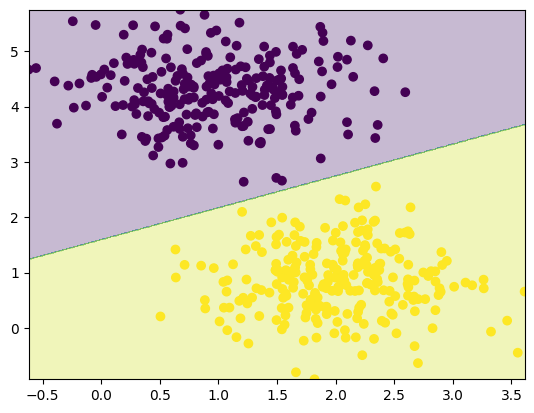

In [4]:
plt.contourf(xx1, xx2, Z_values, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=Y_pred)
plt.show()